# Feature Engineering, Pipelines, and Tuning with sktime

This session covers:

- Time series transformers (in the sklearn sense)
- Manual feature engineering (what not to do)
- Forecasting pipelines
- Time-aware cross-validation
- Hyperparameter tuning


In [ ]:
# !pip install -U sktime matplotlib pandas seaborn statsmodels

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sktime.utils.plotting import plot_series, plot_windows

from sktime.datasets import load_airline
from sktime.forecasting.model_selection import (
    temporal_train_test_split,
    ForecastingGridSearchCV,
    ExpandingWindowSplitter,
)

from sktime.performance_metrics.forecasting import MeanSquaredError
from sktime.forecasting.compose import make_reduction, ForecastingPipeline
from sktime.transformations.series.lag import Lag
from sktime.forecasting.base import ForecastingHorizon

from sklearn.linear_model import Ridge


## Load and visualize data

In [2]:
# TODO: load airline dataset and plot it

y = load_airline()
y.head(5)

Period
1949-01    112.0
1949-02    118.0
1949-03    132.0
1949-04    129.0
1949-05    121.0
Freq: M, Name: Number of airline passengers, dtype: float64

(<Figure size 1600x400 with 1 Axes>,
 <Axes: ylabel='Number of airline passengers'>)

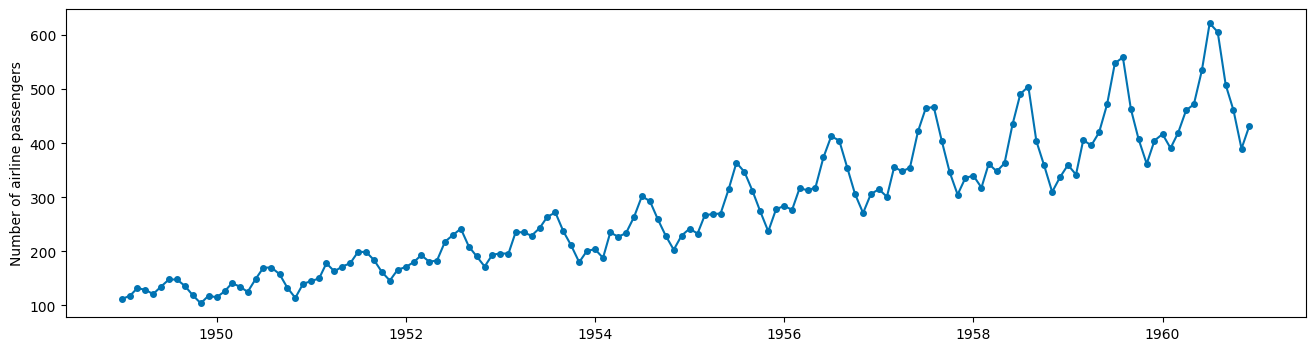

In [3]:
plot_series(y)

## Train/Test Split

In [4]:
# TODO: perform temporal_train_test_split and define fh
y_train, y_test = temporal_train_test_split(y, test_size=24)

fh = ForecastingHorizon(y_test.index, is_relative=False)

In [5]:
fh

ForecastingHorizon(['1959-01', '1959-02', '1959-03', '1959-04', '1959-05', '1959-06',
             '1959-07', '1959-08', '1959-09', '1959-10', '1959-11', '1959-12',
             '1960-01', '1960-02', '1960-03', '1960-04', '1960-05', '1960-06',
             '1960-07', '1960-08', '1960-09', '1960-10', '1960-11', '1960-12'],
            dtype='period[M]', is_relative=False)

## Manual transformations: doing things the wrong way

We manually create lag features outside a forecasting pipeline.


In [6]:
# TODO: manually create lag features

df = pd.DataFrame({'y': y})
df['lag'] = df['y'].shift(1)
df['lag2'] = df['y'].shift(2)
df = df.dropna()

df.head(5)

,y,lag,lag2
1949-03,132.0,118.0,112.0
1949-04,129.0,132.0,118.0
1949-05,121.0,129.0,132.0
1949-06,135.0,121.0,129.0
1949-07,148.0,135.0,121.0


## Reduction-based forecasting

In [61]:
# TODO: build reduction forecaster and generate predictions

forecaster = make_reduction(
    Ridge(),
    window_length=24,
    strategy='recursive'
)

In [62]:
forecaster.fit(y_train)

RecursiveTabularRegressionForecaster(estimator=Ridge(), window_length=24)

In [63]:
y_pred = forecaster.predict(fh) # fh = forecasting horizon

In [64]:
y_pred

1959-01    353.832341
1959-02    319.031644
1959-03    374.349086
1959-04    360.950611
1959-05    390.146389
1959-06    470.924648
1959-07    547.531298
1959-08    563.174405
1959-09    453.514045
1959-10    401.326724
1959-11    354.466310
1959-12    374.763824
1960-01    397.706698
1960-02    350.316578
1960-03    408.775720
1960-04    392.769443
1960-05    430.688469
1960-06    527.788936
1960-07    612.591841
1960-08    633.953790
1960-09    500.882304
1960-10    443.975672
1960-11    389.579587
1960-12    406.076254
Freq: M, Name: Number of airline passengers, dtype: float64

(<Figure size 1600x400 with 1 Axes>,
 <Axes: ylabel='Number of airline passengers'>)

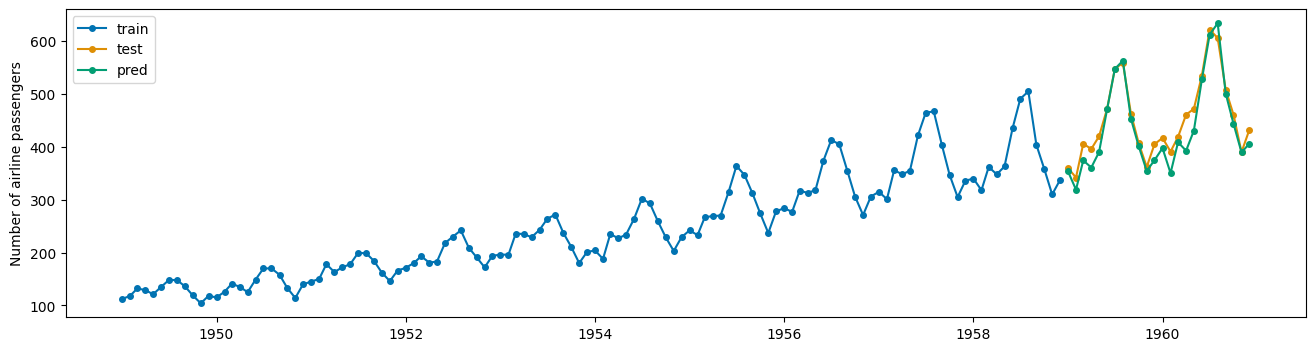

In [65]:
plot_series(y_train, y_test, y_pred, labels=['train', 'test', 'pred'])

## Forecasting pipeline with Lag transformer

In [66]:
# TODO: build ForecastingPipeline with Lag transformer
pipe = ForecastingPipeline(
    steps=[
        ("lags", Lag([1,2,3,12])),
        ("model", make_reduction(Ridge(), strategy='recursive')),
    ]
)

In [67]:
pipe

pipe.fit(y_train)
y_pred = pipe.predict(fh)

In [68]:
y_pred

1959-01    397.276088
1959-02    391.003814
1959-03    382.856728
1959-04    376.753522
1959-05    421.344746
1959-06    483.711857
1959-07    506.500652
1959-08    485.949185
1959-09    414.414271
1959-10    371.285273
1959-11    379.566839
1959-12    406.144990
1960-01    426.477702
1960-02    415.530658
1960-03    405.485907
1960-04    423.971649
1960-05    472.109912
1960-06    517.773749
1960-07    515.605959
1960-08    475.860409
1960-09    432.470926
1960-10    417.625473
1960-11    435.315269
1960-12    453.865275
Freq: M, Name: Number of airline passengers, dtype: float64

(<Figure size 1600x400 with 1 Axes>,
 <Axes: ylabel='Number of airline passengers'>)

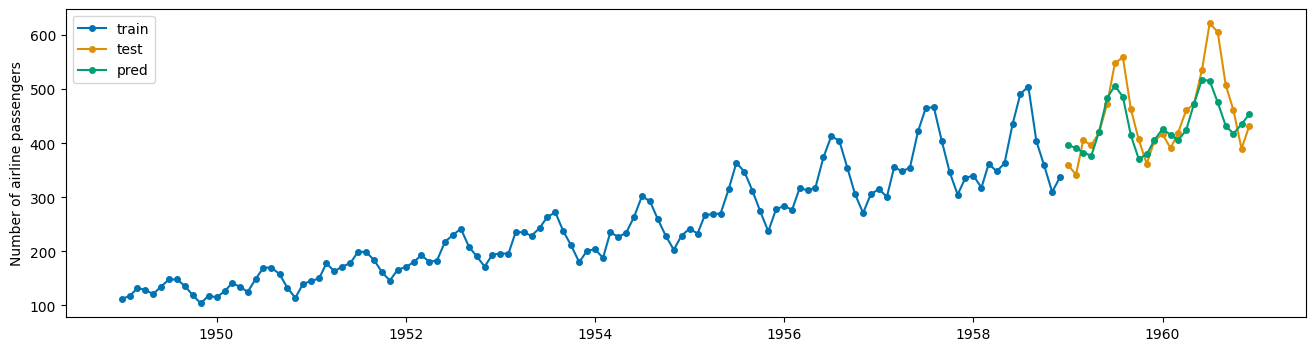

In [69]:
plot_series(y_train, y_test, y_pred, labels=['train', 'test', 'pred'])

## Time series cross-validation

(<Figure size 1600x480 with 1 Axes>,
 <Axes: xlabel='Time', ylabel='Window number'>)

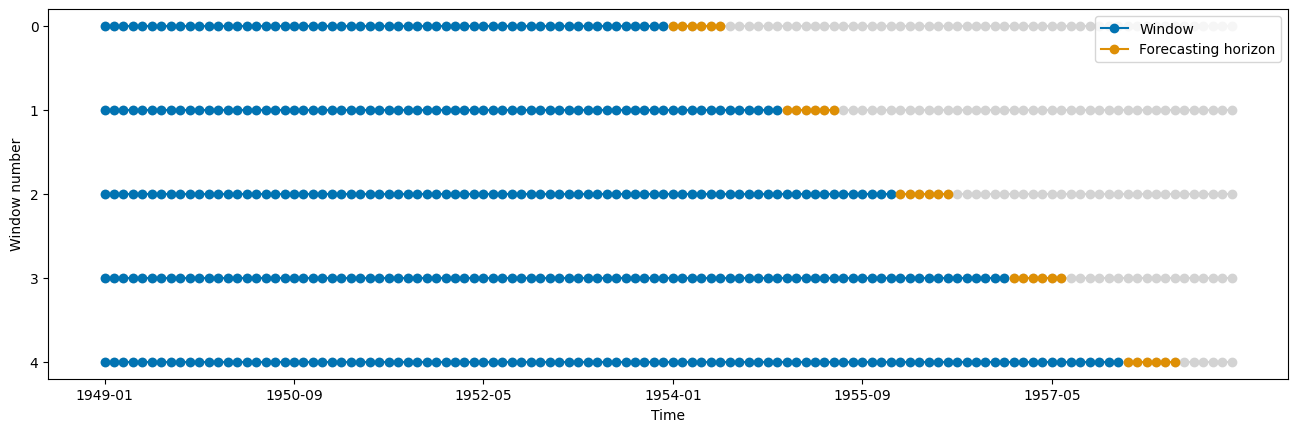

In [70]:
# TODO: set up ExpandingWindowSplitter and ForecastingGridSearchCV
cv = ExpandingWindowSplitter(
    initial_window=60,
    step_length=12,
    fh=[1,2,3,4,5,6]
)

plot_windows(cv=cv, y=y_train)

In [71]:
param_grid = {
    "lags__lags": [[1,2,3], [1,2,3,4], [1,2,3,12]],
    "model__estimator__alpha": [0.01, 0.1, 1, 10], # regularization term for ridge estimator
}

gscv = ForecastingGridSearchCV(
    forecaster=pipe, 
    cv=cv, 
    param_grid=param_grid,
    scoring=MeanSquaredError(square_root=True)
)

# we have created a cross validated forecaster that can be now fit over the training data

gscv.fit(y_train)

ForecastingGridSearchCV(cv=ExpandingWindowSplitter(fh=[1, 2, 3, 4, 5, 6],
                                                   initial_window=60,
                                                   step_length=12),
                        forecaster=ForecastingPipeline(steps=[('lags',
                                                               Lag(lags=[1, 2,
                                                                         3,
                                                                         12])),
                                                              ('model',
                                                               RecursiveTabularRegressionForecaster(estimator=Ridge()))]),
                        param_grid={'lags__lags': [[1, 2, 3], [1, 2, 3, 4],
                                                   [1, 2, 3, 12]],
                                    'model__estimator__alpha': [0.01, 0.1, 1,
                                                                10]},
                        scoring=MeanSquaredError(square_root=True))

In [72]:
gscv.get_fitted_params()['best_params']

{'lags__lags': [1, 2, 3], 'model__estimator__alpha': 10}

In [73]:
gscv.best_forecaster_

ForecastingPipeline(steps=[('lags', Lag(lags=[1, 2, 3])),
                           ('model',
                            RecursiveTabularRegressionForecaster(estimator=Ridge(alpha=10)))])

(<Figure size 1600x400 with 1 Axes>,
 <Axes: ylabel='Number of airline passengers'>)

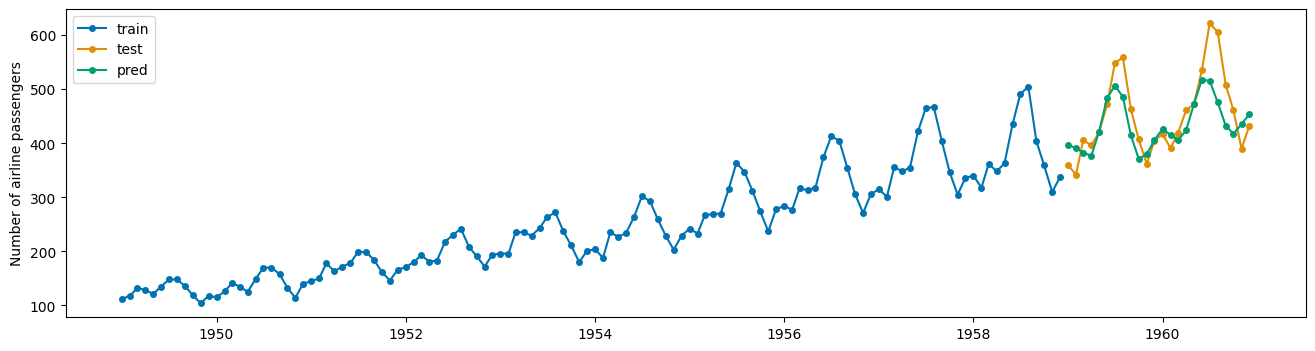

In [74]:
y_pred = gscv.predict(fh)
plot_series(y_train, y_test, y_pred, labels=['train','test','pred'])

## Multiple preprocessing methods and pipelining, with ExponentialSmoothing

In [75]:
# TODO: Multiple pipelines comparison

from sktime.forecasting.exp_smoothing import ExponentialSmoothing
from sklearn.preprocessing import PowerTransformer, RobustScaler, MinMaxScaler
from sktime.forecasting.compose import TransformedTargetForecaster
from sktime.transformations.series.adapt import TabularToSeriesAdaptor
from sktime.transformations.series.detrend import Deseasonalizer, Detrender

In [76]:
forecaster = TransformedTargetForecaster(
    steps=[
        ("detrender", Detrender()),
        ("deseasonalizer", Deseasonalizer()),
        ("minmax", TabularToSeriesAdaptor(MinMaxScaler((1, 10)))),
        ("power", TabularToSeriesAdaptor(PowerTransformer())),
        ("scaler", TabularToSeriesAdaptor(RobustScaler())),
        ("forecaster", ExponentialSmoothing()),
    ]
)

In [77]:
# PARAMETER FORMAT
# {step}__{parameter}
param_grid = {
    # deseasonalizer
    "deseasonalizer__model": ["multiplicative", "additive"],
    # power
    "power__transformer__method": ["box-cox", "yeo-johnson"],
    "power__transformer__standardize": [True, False],
    # forecaster
        # sp = span (time window, think lag)
    "forecaster__sp": [4,6,12],
    "forecaster__seasonal": ["add", "mul"],
    "forecaster__trend": ["add", "mul"],
    "forecaster__damped_trend": [True, False],
}

In [78]:
gscv = ForecastingGridSearchCV(
    forecaster=forecaster,
    param_grid=param_grid,
    cv=cv,
    verbose=1,
    n_jobs=-1, # if have multiple processors, can use n processors
    scoring=MeanSquaredError(square_root=True)
)

gscv.fit(y_train)

Fitting 5 folds for each of 192 candidates, totalling 960 fits


ForecastingGridSearchCV(cv=ExpandingWindowSplitter(fh=[1, 2, 3, 4, 5, 6],
                                                   initial_window=60,
                                                   step_length=12),
                        forecaster=TransformedTargetForecaster(steps=[('detrender',
                                                                       Detrender()),
                                                                      ('deseasonalizer',
                                                                       Deseasonalizer()),
                                                                      ('minmax',
                                                                       TabularToSeriesAdaptor(transformer=MinMaxScaler(feature_range=(1, 10)))),
                                                                      ('power',
                                                                       TabularToSeriesAdaptor(transformer=PowerTransform...
                        param_grid={'deseasonalizer__model': ['multiplicative',
                                                              'additive'],
                                    'forecaster__damped_trend': [True, False],
                                    'forecaster__seasonal': ['add', 'mul'],
                                    'forecaster__sp': [4, 6, 12],
                                    'forecaster__trend': ['add', 'mul'],
                                    'power__transformer__method': ['box-cox',
                                                                   'yeo-johnson'],
                                    'power__transformer__standardize': [True,
                                                                        False]},
                        scoring=MeanSquaredError(square_root=True), verbose=1)

In [79]:
y_pred = gscv.predict(fh)

(<Figure size 1600x400 with 1 Axes>,
 <Axes: ylabel='Number of airline passengers'>)

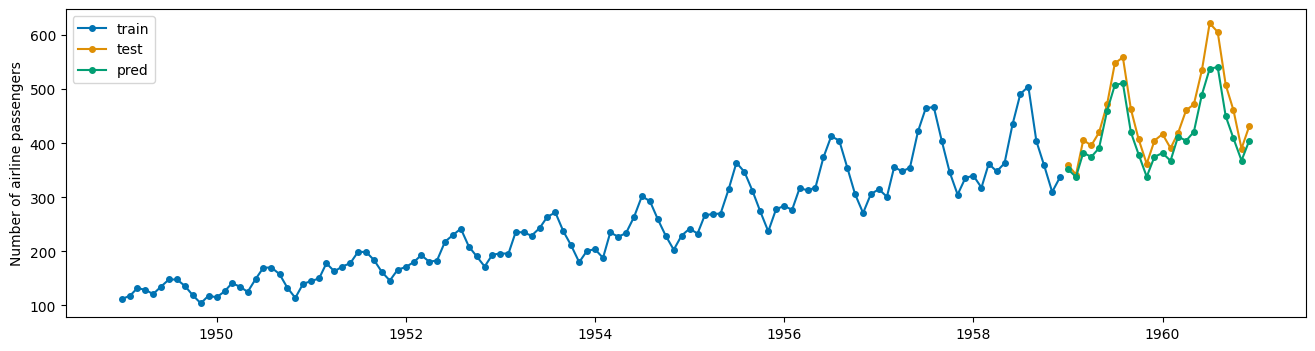

In [80]:
plot_series(y_train, y_test, y_pred, labels=['train','test','pred'])